In [2]:
import pandas as pd
import plotnine as p9
import numpy as np
import scanpy as sc

In [3]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [4]:
barnyard_OAK1_adata=sc.read_h5ad(data_dir+'/barnyard_OAK150kali1/adata_raw.h5ad')

In [60]:
K562_OAK1_adata=barnyard_OAK1_adata[barnyard_OAK1_adata.obs.call.isin(['GRCh38']),barnyard_OAK1_adata.var.species.isin(['GRCh38'])]

In [61]:
df_geneSummary_K562_OAK1=pd.DataFrame(columns=['nUMI_Mean'],index=K562_OAK1_adata.var.gene_id)

In [62]:
df_geneSummary_K562_OAK1['nUMI_Mean']=K562_OAK1_adata.X.mean(axis=0).tolist()[0] 

In [63]:
df_geneSummary_K562_OAK1['nUMI_Sum']=K562_OAK1_adata.X.sum(axis=0).tolist()[0] 

In [64]:
df_geneSummary_K562_OAK1['exp']='OAK'

In [9]:
barnyard_NextGEM3p_adata=sc.read_h5ad(data_dir+'/barnyard_10x/Downsampling/adata.h5ad')

In [10]:
barnyard_NextGEM3p_adata.var[['species','gene_id']]=barnyard_NextGEM3p_adata.var.iloc[:,0].str.split("_",expand=True) 

In [65]:
barnyard_NextGEM3p_adata_matchsize=sc.pp.subsample(barnyard_NextGEM3p_adata,n_obs=3647,copy=True)

In [74]:
df_geneSummary_K562_NextGEM3p=pd.DataFrame(columns=['nUMI_Mean'],index=barnyard_NextGEM3p_adata_matchsize.var.gene_id)

In [75]:
df_geneSummary_K562_NextGEM3p.nUMI_Mean=barnyard_NextGEM3p_adata_matchsize.X.mean(axis=0)

In [76]:
df_geneSummary_K562_NextGEM3p['nUMI_Sum']=barnyard_NextGEM3p_adata_matchsize.X.sum(axis=0)

In [77]:
df_geneSummary_K562_NextGEM3p['exp']='Chromium'

In [78]:
df_geneSummary=pd.concat([df_geneSummary_K562_NextGEM3p,df_geneSummary_K562_OAK1])

In [79]:
df_geneSummary

,nUMI_Mean,nUMI_Sum,exp
gene_id,,,
ENSG00000000003,0.000274,1.0,Chromium
ENSG00000000005,0.000000,0.0,Chromium
ENSG00000000419,0.868659,3168.0,Chromium
ENSG00000000457,0.136276,497.0,Chromium
ENSG00000000460,0.496024,1809.0,Chromium
...,...,...,...
ENSG00000277836,0.000000,0.0,OAK
ENSG00000278633,0.000000,0.0,OAK
ENSG00000276017,0.000000,0.0,OAK


In [19]:
MANE=pd.read_csv(data_dir+'/biomart_ensembl_MANE_tx_len.csv',header=0)

In [20]:
MANE

,hgnc_symbol,ensembl_gene_id,ensembl_transcript_id,ensembl_transcript_id.1,transcript_length
0,OR9G9,ENSG00000262191,ENST00000571130,ENST00000571130,918
1,PRY,ENSG00000169789,ENST00000303728,ENST00000303728,1238
2,USP9Y,ENSG00000114374,ENST00000338981,ENST00000338981,10036
3,PRY2,ENSG00000169807,ENST00000303804,ENST00000303804,1238
4,EIF1AY,ENSG00000198692,ENST00000361365,ENST00000361365,1339
...,...,...,...,...,...
19247,CNKSR1,ENSG00000142675,ENST00000361530,ENST00000361530,2535
19248,NaN,ENSG00000288644,ENST00000675181,ENST00000675181,99
19249,NaN,ENSG00000288626,ENST00000675347,ENST00000675347,207
19250,NaN,ENSG00000288629,ENST00000676334,ENST00000676334,63


In [80]:
df_geneSummary=df_geneSummary.reset_index().merge(MANE,how="inner",left_on=['gene_id'],right_on=["ensembl_gene_id"]).set_index('gene_id') 

In [81]:
df_geneSummary

,nUMI_Mean,nUMI_Sum,exp,hgnc_symbol,ensembl_gene_id,ensembl_transcript_id,ensembl_transcript_id.1,transcript_length
gene_id,,,,,,,,
ENSG00000000003,0.000274,1.0,Chromium,TSPAN6,ENSG00000000003,ENST00000373020,ENST00000373020,3768
ENSG00000000003,0.000823,3.0,OAK,TSPAN6,ENSG00000000003,ENST00000373020,ENST00000373020,3768
ENSG00000000005,0.000000,0.0,Chromium,TNMD,ENSG00000000005,ENST00000373031,ENST00000373031,1205
ENSG00000000005,0.000000,0.0,OAK,TNMD,ENSG00000000005,ENST00000373031,ENST00000373031,1205
ENSG00000000419,0.868659,3168.0,Chromium,DPM1,ENSG00000000419,ENST00000371588,ENST00000371588,1054
...,...,...,...,...,...,...,...,...
ENSG00000287363,0.000000,0.0,OAK,CIMIP3,ENSG00000287363,ENST00000623004,ENST00000623004,579
ENSG00000287585,0.000000,0.0,Chromium,NaN,ENSG00000287585,ENST00000653668,ENST00000653668,443
ENSG00000287585,0.000548,2.0,OAK,NaN,ENSG00000287585,ENST00000653668,ENST00000653668,443


/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10


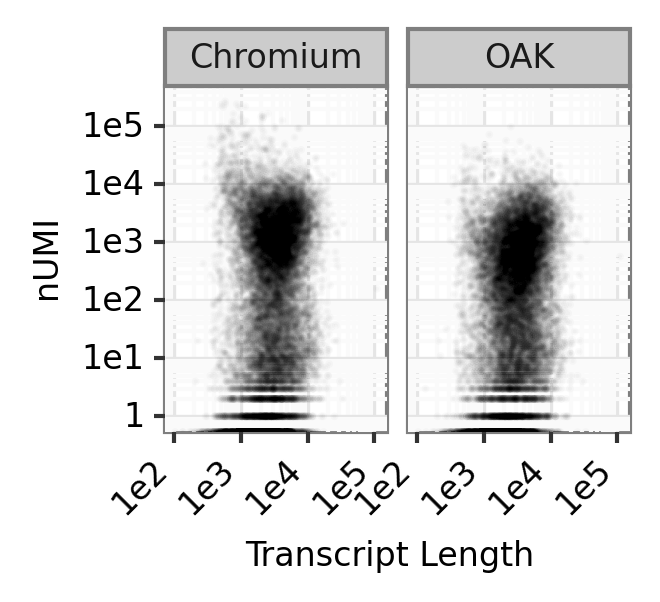

<ggplot: (2932181947055)>

In [95]:
plot=p9.ggplot(data=df_geneSummary,
               mapping=p9.aes(x='transcript_length',y='nUMI_Sum')
              )
plot+ p9.geom_point(alpha=0.02,size=0.05) \
+ p9.themes.theme_bw() \
+ p9.facet_wrap('exp') \
+ p9.theme(axis_text_x=p9.element_text(colour="black",angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(colour="black")) \
+ p9.theme(text=p9.element_text(size=8),legend_position='right',legend_title=p9.element_blank(),legend_direction='vertical',legend_key=p9.element_blank(),legend_key_size=5,legend_box_margin=0) \
+ p9.guides(color = p9.guide_legend(override_aes={'size' :1,'alpha':0.5 })) \
+ p9.scales.scale_x_log10(breaks=[100,1000,10000,100000]) \
+ p9.scales.scale_y_log10(breaks=[0.1,1,10,100,1000,10000,100000]) \
+ p9.labels.ylab('nUMI') \
+ p9.labels.xlab('Transcript Length') \
+ p9.theme(figure_size=(2,1.5)) # inch

In [96]:
df_geneSummary[df_geneSummary.exp=='Chromium'][['nUMI_Sum','transcript_length']].corr(method="spearman") 

,nUMI_Sum,transcript_length
nUMI_Sum,1.000000,0.198941
transcript_length,0.198941,1.000000


In [97]:
df_geneSummary[df_geneSummary.exp=='OAK'][['nUMI_Sum','transcript_length']].corr(method="spearman") 

,nUMI_Sum,transcript_length
nUMI_Sum,1.000000,0.264235
transcript_length,0.264235,1.000000
